In [2]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()


def generate_bc03_reference(sfr,age_max, metallicity=0.6, z=0.0):

    model_components = {}

    model_components["constant"] = {
        "age_max": age_max,
        "age_min": 0.,
        "massformed":np.log10(sfr * (age_max * 1e9)),
        "metallicity": metallicity
    }


    model_components["dust"] = {
        "type": "Calzetti",
        "Av": 0.0,
        "eta": 1.0
    }

    # model_components["nebular"] = {
    #     "logU": -3,
    #     "lines_width": 300.0
    # }

    model_components["redshift"] = z


    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(500, 8000, 5)) # 不传滤光片，只生成光谱

    wavelengths = model.spectrum[:, 0]
    fluxes = model.spectrum[:, 1]

    return wavelengths, fluxes




1102


In [3]:
model_wave, model_flux = generate_bc03_reference(sfr=5,age_max=0.25)

wavelength_range=(5400,5600)
target_flux=1.e-19
target_region = wavelength_range

flux_densities_in_region = []
wavelength=model_wave
flux_lambda=model_flux

flux_density_in_region = FL.flux_density(wavelength, flux_lambda, target_region)

normalization_value=np.nanmedian(flux_density_in_region) if target_flux is None else target_flux
normalization_factors = normalization_value / flux_density_in_region

normalized_flux_lambda = flux_lambda * normalization_factors

In [3]:
group_conditions = [(-0.05,0.02), (0.02,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.45),(0.45,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

Categorizing catalog entries...
Group 0: 102 spectra, Mean BD = 0.000
Group 4: 69 spectra, Mean BD = 0.363
Group 2: 150 spectra, Mean BD = 0.147
Group 5: 44 spectra, Mean BD = 0.517
Group 3: 111 spectra, Mean BD = 0.246
Group 1: 148 spectra, Mean BD = 0.062
Applied masks to 8 regions.
Group 0 processed successfully.
Applied masks to 8 regions.
Group 1 processed successfully.
Applied masks to 8 regions.
Group 2 processed successfully.
Applied masks to 8 regions.
Group 3 processed successfully.
Applied masks to 8 regions.
Group 4 processed successfully.
Applied masks to 8 regions.
Group 5 processed successfully.
Group 0 spectrum smoothed and stored as 'average_flux_smoothed'.


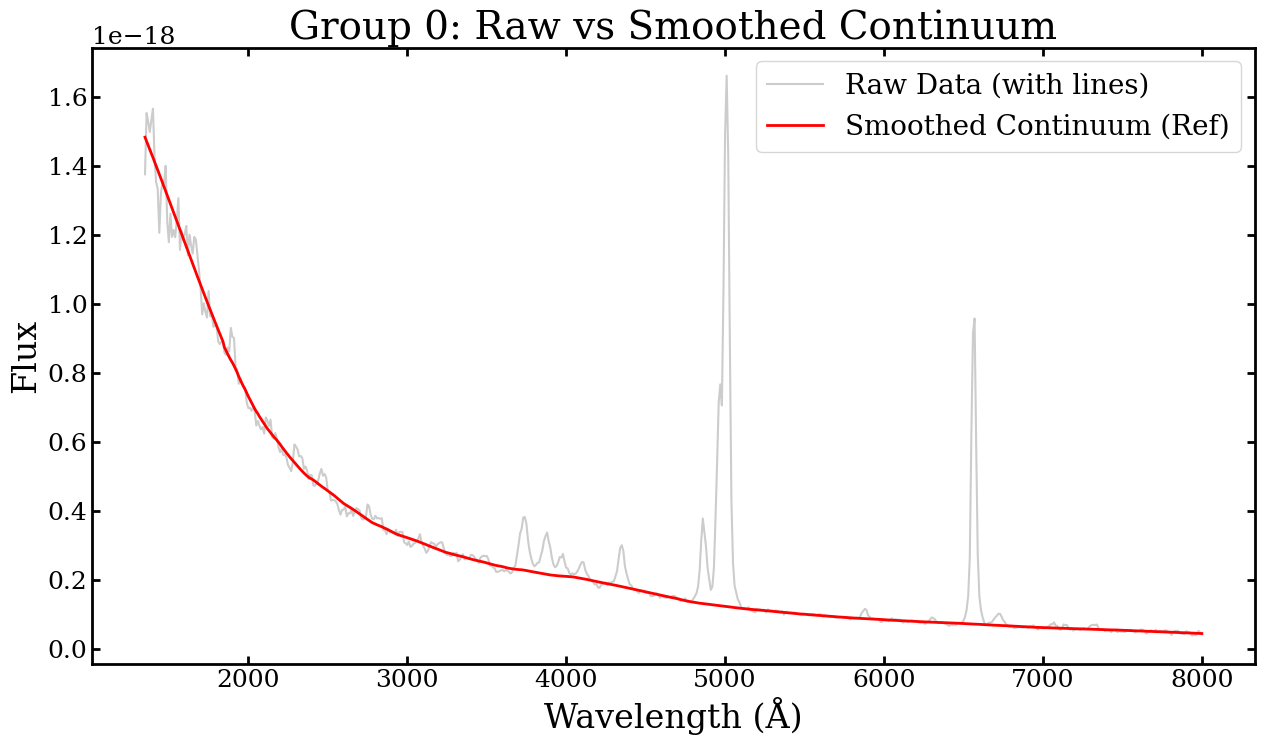

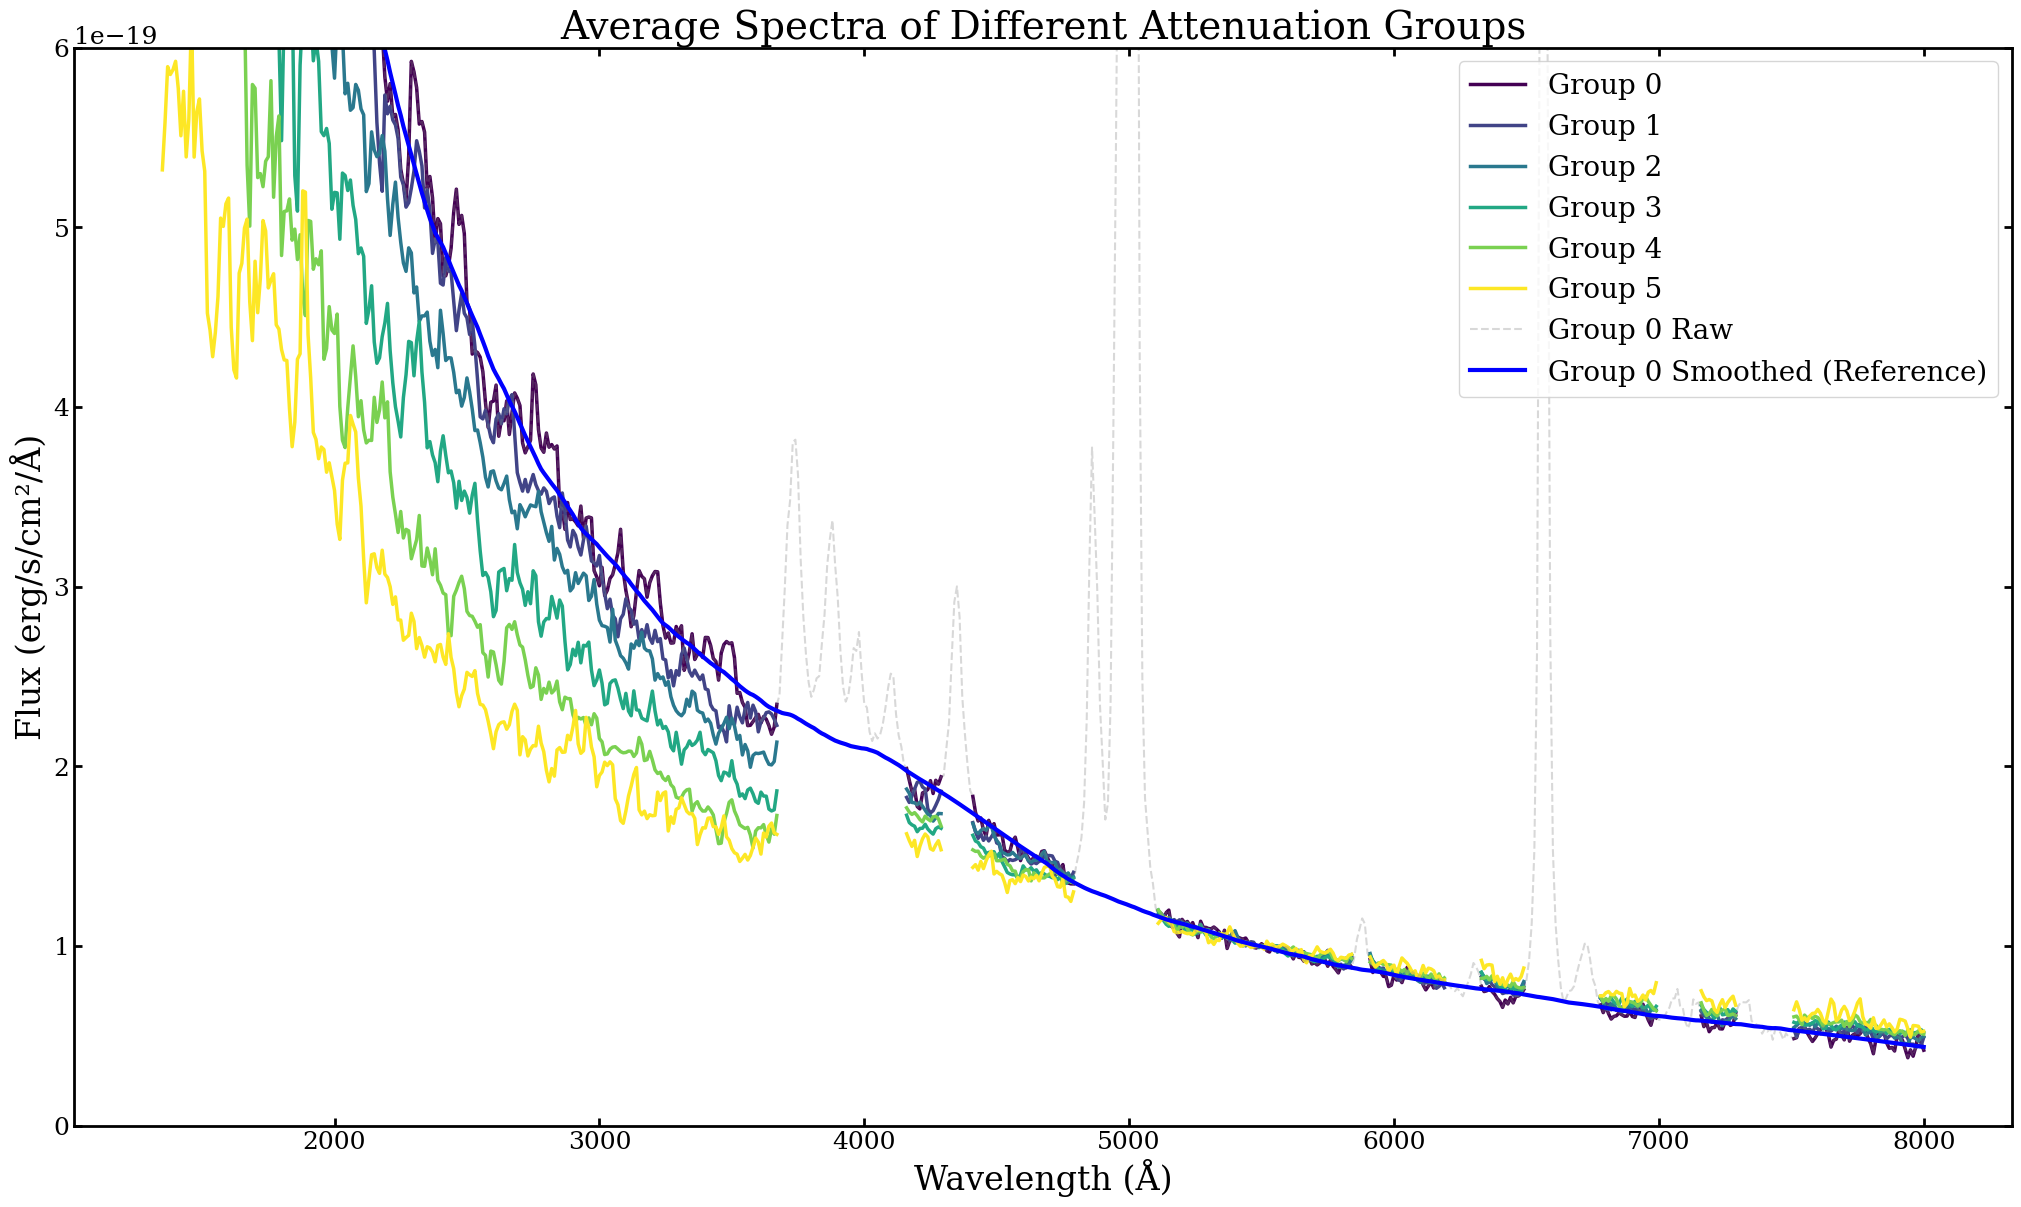

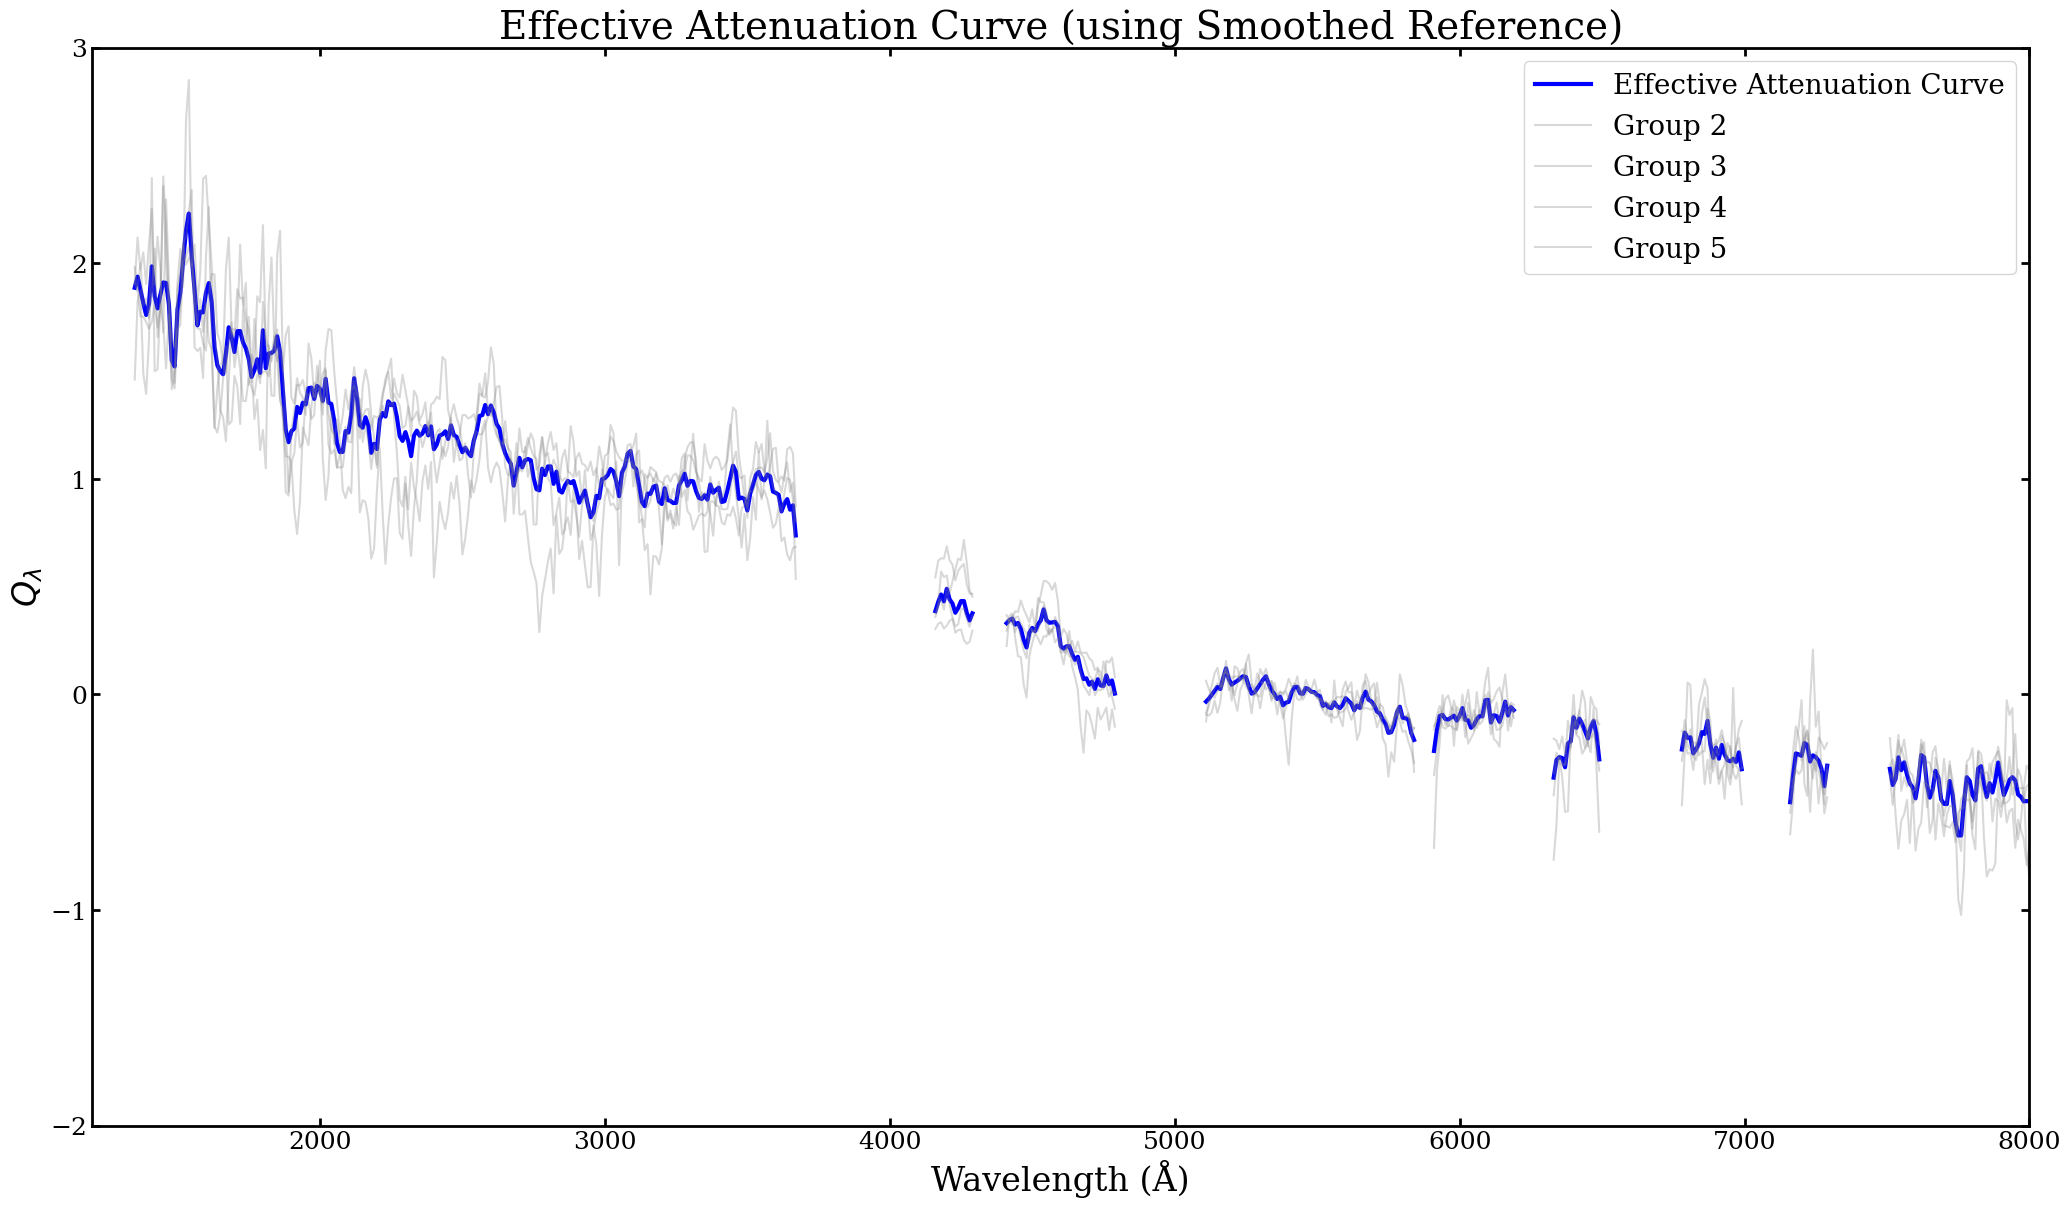

In [4]:
group_conditions = [(-0.05,0.02), (0.02,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.45),(0.45,0.6)]
def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return -1

from scipy.signal import savgol_filter
# ==========================================
# 1. 准备工作：分组与统计
# ==========================================

# 存储每组的 ID 列表
group_keys = defaultdict(list)
# 存储每组所有的 Balmer Decrement 值（用于计算组平均值）
group_decrement_values = defaultdict(list)

print("Categorizing catalog entries...")

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    # 基础过滤
    if not catalog['sample_flag']:
        continue

    try:
        # 获取参数
        line_params = catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']
        halpha_flux = line_params['halpha_flux']
        hbeta_flux = line_params['hbeta_flux']

        # 安全检查
        if hbeta_flux <= 0 or halpha_flux <= 0:
            continue

        # 计算单源的 Balmer Decrement
        bd_value = np.log(halpha_flux / hbeta_flux / 2.86)

        # 获取组号 (假设你有一个 group_condition_func 函数)
        group_index = group_condition_func(bd_value)

        if group_index != -1:
            group_keys[group_index].append(surveyid_subid)
            group_decrement_values[group_index].append(bd_value)

    except Exception as e:
        continue

# 计算每组的平均 Balmer Decrement
group_mean_decrement = {}
for idx, values in group_decrement_values.items():
    group_mean_decrement[idx] = np.mean(values)
    if idx==0:
        group_mean_decrement[idx]=0.0
    print(f"Group {idx}: {len(values)} spectra, Mean BD = {group_mean_decrement[idx]:.3f}")

# ==========================================
# 2. 批量处理光谱 (Averaging & Masking)
# ==========================================

# 定义发射线 Mask 区域
mask_regions = [
    (3675, 4150), (4300, 4400), (4800, 5100),
    (5850, 5900),(6200, 6325), (6500, 6775),
    (7000, 7150), (7300, 7500)
]


# 存储所有处理好的 Averager 对象
averagers = {}

# 按顺序处理存在的组
sorted_group_ids = sorted(group_keys.keys())

for group_idx in sorted_group_ids:
    keys = group_keys[group_idx]

    # 实例化
    # 注意：这里假设 FL.SpectrumAverager 是你最新的包含 apply_emission_line_mask 的类
    averager = FL.SpectrumAverager()

    # 加载 (需要传入你的读取函数 Load_Spectrum_From_Fits)
    success = averager.load_spectrum_catalog(keys, DJAv4Catalog, load_func=FL.Load_Spectrum_From_Fits)

    if not success:
        print(f"Group {group_idx} load failed.")
        continue

    # 处理流程
    averager.create_common_wavelength_grid(wavelength_range=(1350, 8000), grid_size=10)
    averager.interpolate_spectra(interpolation_method='linear')
    averager.spectrum_normalization_within_range(wavelength_range=(5400, 5600), target_flux=1.e-19)

    # 计算平均谱 (此时生成的是 Raw)
    averager.compute_average_spectrum(
        method='median',
        ignore_nan=True,
        use_percentile_filter=True,
        lower_percentile=16,
        upper_percentile=84
    )

    # 【关键步骤】应用 Mask
    averager.apply_emission_line_mask(mask_regions)

    # 存入字典
    averagers[group_idx] = averager
    print(f"Group {group_idx} processed successfully.")


ref_averager = averagers[0] # 假设你使用字典结构，或者使用 group0_averager

# 准备数据
wavelengths = ref_averager.common_wavelength # 单位 Angstrom
flux_raw = ref_averager.average_flux_raw   # 原始含发射线数据

# --- 参数设置 ---
# grid_size=10A, window_length=51 代表 510A 的平滑窗口，适合提取大尺度连续谱
# polyorder=3 适合保留一定的光谱特征（如 Balmer Break）
sg_window_length = 100
sg_polyorder = 3

# --- 步骤 A: 预处理 (Mask Emission Lines) ---
# 先复制一份数据，用于处理
flux_for_smoothing = flux_raw.copy()

# 将发射线区域设为 NaN (类似于你之前的 mask 逻辑，但在原数组上操作)
# 注意：这里直接使用 Angstrom，不需要除以 10000，保持单位统一
for (low, high) in mask_regions:
    mask_indices = (wavelengths >= low) & (wavelengths <= high)
    flux_for_smoothing[mask_indices] = np.nan

# --- 步骤 B: 插值填补 (Interpolation) ---
# 使用 Pandas 强大的插值功能填补 NaN，连接发射线两侧的连续谱
series_flux = pd.Series(flux_for_smoothing)
# limit_direction='both' 确保边缘也能被填补
flux_interpolated = series_flux.interpolate(method='linear', limit_direction='both').to_numpy()

# --- 步骤 C: SG 平滑 (Savitzky-Golay Filter) ---
# 现在 flux_interpolated 是连续的，没有 NaN，可以直接放入 sg_filter
flux_smoothed = savgol_filter(flux_interpolated, window_length=sg_window_length, polyorder=sg_polyorder)

# --- 步骤 D: 存储 ---
# 将平滑后的数据存回对象，方便后续调用
ref_averager.average_flux_smoothed = flux_smoothed

print("Group 0 spectrum smoothed and stored as 'average_flux_smoothed'.")

# --- 可视化检查 (这一步很重要，看看平滑是否过度或不足) ---
plt.figure(figsize=(15, 8))
plt.plot(wavelengths, flux_raw, color='gray', alpha=0.4, label='Raw Data (with lines)')
plt.plot(wavelengths, flux_smoothed, color='red', linewidth=2, label='Smoothed Continuum (Ref)')
plt.title('Group 0: Raw vs Smoothed Continuum')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.legend()
plt.show()


# ==========================================
# 3. 计算 Tau 和 Q 曲线
# ==========================================

if 0 not in averagers:
    raise ValueError("Group 0 (Reference Group) is missing! Cannot compute attenuation curves.")

# 获取基准数据 (Group 0)
# 使用 masked 数据，避免发射线影响比值
ref_flux = averagers[0].average_flux_masked
ref_decrement = group_mean_decrement[0]
curves_results = {}
ref_flux_smooth = averagers[0].average_flux_smoothed # 使用刚刚生成的平滑谱
ref_decrement = group_mean_decrement[0]

# 遍历计算
for i in sorted(averagers.keys()):
    if i == 0: continue

    target_averager = averagers[i]
    # 分子：使用 Mask 后的数据 (发射线处为 NaN)，这样结果图中发射线位置是断开的
    target_flux = target_averager.average_flux_masked
    target_decrement = group_mean_decrement[i]

    # 1. 计算 Tau (Optical Depth)
    # 分母由 smoothed 谱提供，它是连续且光滑的，不会引入额外的噪声
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = target_flux / ref_flux_smooth
        tau_lambda = -np.log(ratio)

    # 2. 计算 Q (Attenuation Curve)
    delta_bd = target_decrement - ref_decrement

    if delta_bd == 0:
        Q_lambda = np.full_like(tau_lambda, np.nan)
    else:
        Q_lambda = tau_lambda / delta_bd

    curves_results[i] = {
        'wavelength': target_averager.common_wavelength,
        'tau_lambda': tau_lambda, # 这里的 tau 在发射线处会是 NaN
        'Q_lambda': Q_lambda,
        'delta_bd': delta_bd
    }

# ==========================================
# 4. 可视化结果
# ==========================================

# 1. 画 Group 0 的对比 (Raw vs Smoothed)
# 为了不喧宾夺主，我们可以用虚线画 Raw，实线画 Smoothed
# 注意：这里 Q 曲线和 Flux 量级不同，不能画在一个轴上。
# 通常我们会把 Flux 画在一个子图，Q 曲线画在另一个子图。
# 但如果你想画在一起，我假设你是想画 Q 曲线结果：

# --- 下面是画 Q 曲线的代码 (Effective Curve) ---
# 如果你想画的是 Q 曲线，请忽略上面画 Flux 的两行，使用下面的逻辑：

# 计算 Effective Curve (加权平均)
target_groups = [2, 3, 4, 5] # 根据你的选择
q_list = [curves_results[g]['Q_lambda'] for g in target_groups if g in curves_results]
w_list = [curves_results[g]['delta_bd'] for g in target_groups if g in curves_results]


group_ids = sorted(averagers.keys())
num_groups = len(group_ids)

# 【修正点1】生成均匀分布的颜色 (0到1之间)
# 如果只有1组，避免 linspace 生成 [0]，强制使用 [0.5] 或其他
if num_groups > 1:
    colors = plt.cm.viridis(np.linspace(0, 1, num_groups))
else:
    colors = [plt.cm.viridis(0.5)]

fig, ax = plt.subplots(figsize=(25, 14))

for i, group_idx in enumerate(group_ids):
    averager = averagers[group_idx]

    # 【修正点2】优先绘制 Mask 后的连续谱
    # 如果该组应用了 apply_emission_line_mask，我们画 masked 数据
    if averager.average_flux_masked is not None:
        flux_to_plot = averager.average_flux_masked
    else:
        flux_to_plot = averager.average_flux

    # 绘制
    ax.plot(averager.common_wavelength, flux_to_plot,
            color=colors[i],
            linewidth=2.5, #稍微加粗一点
            label=f'Group {group_idx}')
ref_wave = averagers[0].common_wavelength
ax.plot(ref_wave, averagers[0].average_flux_raw, color='gray', alpha=0.3, linestyle='--', label='Group 0 Raw')
ax.plot(ref_wave, averagers[0].average_flux_smoothed, color='blue', linewidth=3, linestyle='-', label='Group 0 Smoothed (Reference)')

# --- 以下保留你的样式设置 ---

ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=24)
ax.legend(fontsize=20)


ax.set_title('Average Spectra of Different Attenuation Groups', fontsize=28)

# 根据实际归一化情况调整 Y 轴
# 如果你归一化到了 1e-19，这里范围可能需要微调
ax.set_ylim(0, 6e-19)
# ax.set_ylim(1e-20, 6e-19) # 你的原始设置

# 保存与显示
# plt.savefig('Average_Spectra_of_Different_Attenuation_Groups_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()





fig, ax = plt.subplots(figsize=(25, 14))

if q_list:
    stack_q = np.ma.masked_invalid(np.array(q_list)) # 忽略 NaN
    effective_curve = np.ma.average(stack_q, axis=0, weights=w_list).filled(np.nan)

    # 画 Effective Curve
    ax.plot(ref_wave, effective_curve, color='blue', linewidth=3, label='Effective Attenuation Curve')


    # 画各个 Group 的 Q (作为背景)
    for g in target_groups:
        if g in curves_results:
            ax.plot(curves_results[g]['wavelength'], curves_results[g]['Q_lambda'],
                    color='gray', alpha=0.3, label=f'Group {g}')

# 设置
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$Q_\lambda$', fontsize=24) # 或者 Flux，看你想画哪个
ax.set_title('Effective Attenuation Curve (using Smoothed Reference)', fontsize=28)
ax.legend(fontsize=20)
ax.set_ylim(-2, 3) # 针对 Q 曲线的范围
ax.set_xlim(1200, 8000)

plt.show()

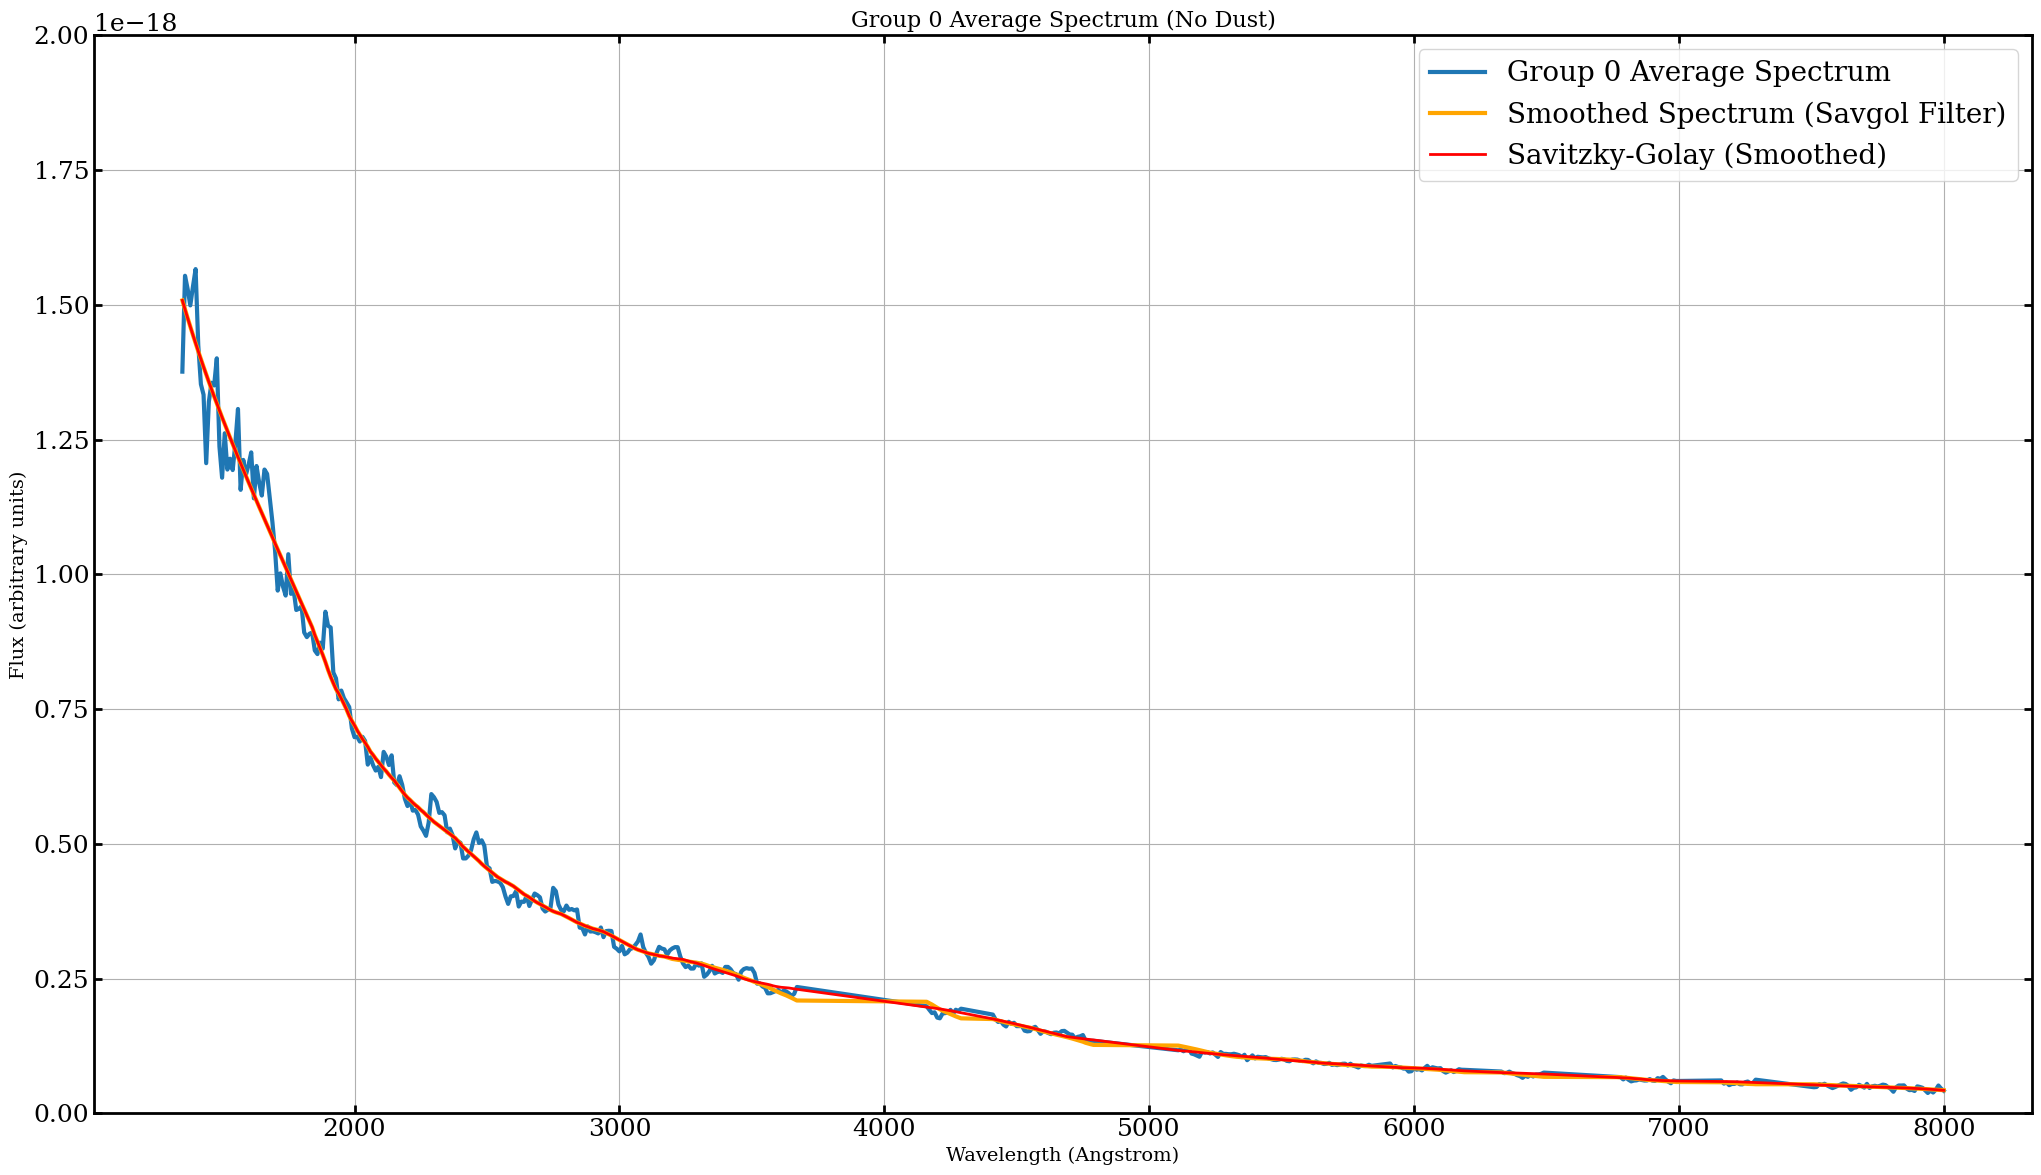

In [8]:
from scipy.signal import savgol_filter

mask_regions = [
    (3675, 4150), (4300, 4400), (4800, 5100),
    (5850, 5900),(6200, 6325), (6500, 6775),
    (7000, 7150), (7300, 7500)
]
window_len = 100
poly_order = 4


wavelengths=averagers[0].common_wavelength/10000
averaged_flux=averagers[0].average_flux


series_curve = pd.Series(averaged_flux, index=wavelengths)
curve_clean = series_curve.replace([np.inf, -np.inf], np.nan).interpolate(method='linear', limit_direction='both')
curve_clean = curve_clean.to_numpy()

mask=np.ones_like(wavelengths, dtype=bool)
for (low, high) in mask_regions:
    low, high = float(low)/10000, float(high)/10000
    mask &= ~((wavelengths >= low) & (wavelengths <= high))

valid_data=np.isfinite(curve_clean) & np.isfinite(wavelengths) & mask

g0_smoothed_curve = savgol_filter(curve_clean[valid_data], window_length=window_len, polyorder=poly_order)


plt.plot(wavelengths[valid_data]*10000, averagers[0].average_flux[valid_data], lw=3,label='Group 0 Average Spectrum')
plt.plot(wavelengths[valid_data]*10000, g0_smoothed_curve, 'orange', lw=3, label='Smoothed Spectrum (Savgol Filter)')
plt.plot(x_data[valid_data], sg_smooth[valid_data],
         color='red', lw=2, label='Savitzky-Golay (Smoothed)')
# plt.plot(model_wave, normalized_flux_lambda, 'r--', lw=2, label='BC03/Bagpipes Model (No Dust, 100 Myr)')

plt.xlabel('Wavelength (Angstrom)', fontsize=14)
plt.ylabel('Flux (arbitrary units)', fontsize=14)
plt.title('Group 0 Average Spectrum (No Dust)', fontsize=16)
plt.ylim(0,2e-18)
plt.legend()
plt.grid()

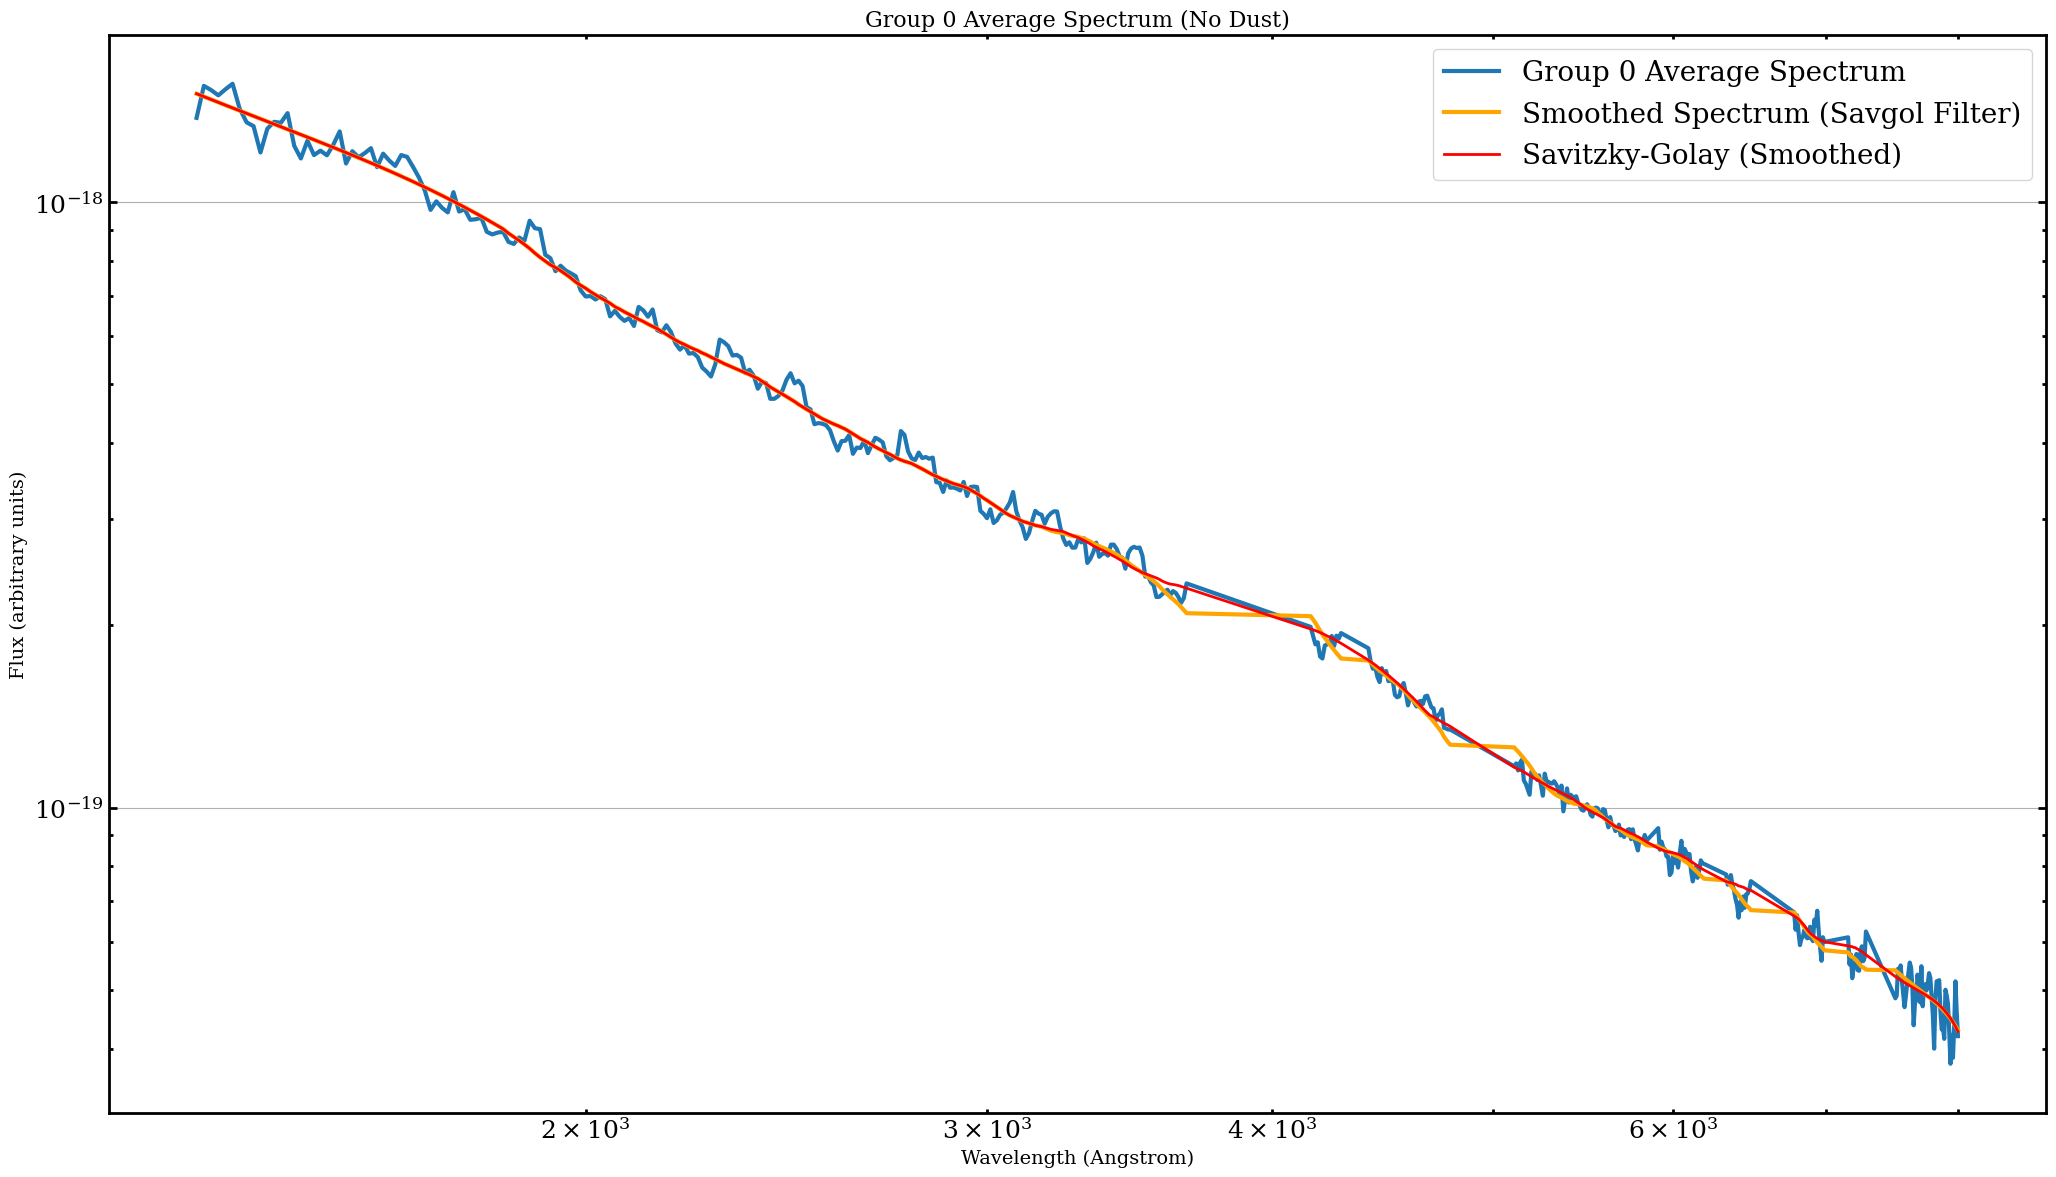

In [10]:
mask_regions = [
    (3675, 4150), (4300, 4400), (4800, 5100),
    (5850, 5900),(6200, 6325), (6500, 6775),
    (7000, 7150), (7300, 7500)
]
window_len = 100
poly_order = 4


wavelengths=averagers[0].common_wavelength/10000
averaged_flux=averagers[0].average_flux


series_curve = pd.Series(averaged_flux, index=wavelengths)
curve_clean = series_curve.replace([np.inf, -np.inf], np.nan).interpolate(method='linear', limit_direction='both')
curve_clean = curve_clean.to_numpy()

mask=np.ones_like(wavelengths, dtype=bool)
for (low, high) in mask_regions:
    low, high = float(low)/10000, float(high)/10000
    mask &= ~((wavelengths >= low) & (wavelengths <= high))

valid_data=np.isfinite(curve_clean) & np.isfinite(wavelengths) & mask

g0_smoothed_curve = savgol_filter(curve_clean[valid_data], window_length=window_len, polyorder=poly_order)


plt.plot(wavelengths[valid_data]*10000, averagers[0].average_flux[valid_data], lw=3,label='Group 0 Average Spectrum')
plt.plot(wavelengths[valid_data]*10000, g0_smoothed_curve, 'orange', lw=3, label='Smoothed Spectrum (Savgol Filter)')
plt.plot(x_data[valid_data], sg_smooth[valid_data],
         color='red', lw=2, label='Savitzky-Golay (Smoothed)')
# plt.plot(model_wave, normalized_flux_lambda, 'r--', lw=2, label='BC03/Bagpipes Model (No Dust, 100 Myr)')

plt.xlabel('Wavelength (Angstrom)', fontsize=14)
plt.ylabel('Flux (arbitrary units)', fontsize=14)
plt.title('Group 0 Average Spectrum (No Dust)', fontsize=16)

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()

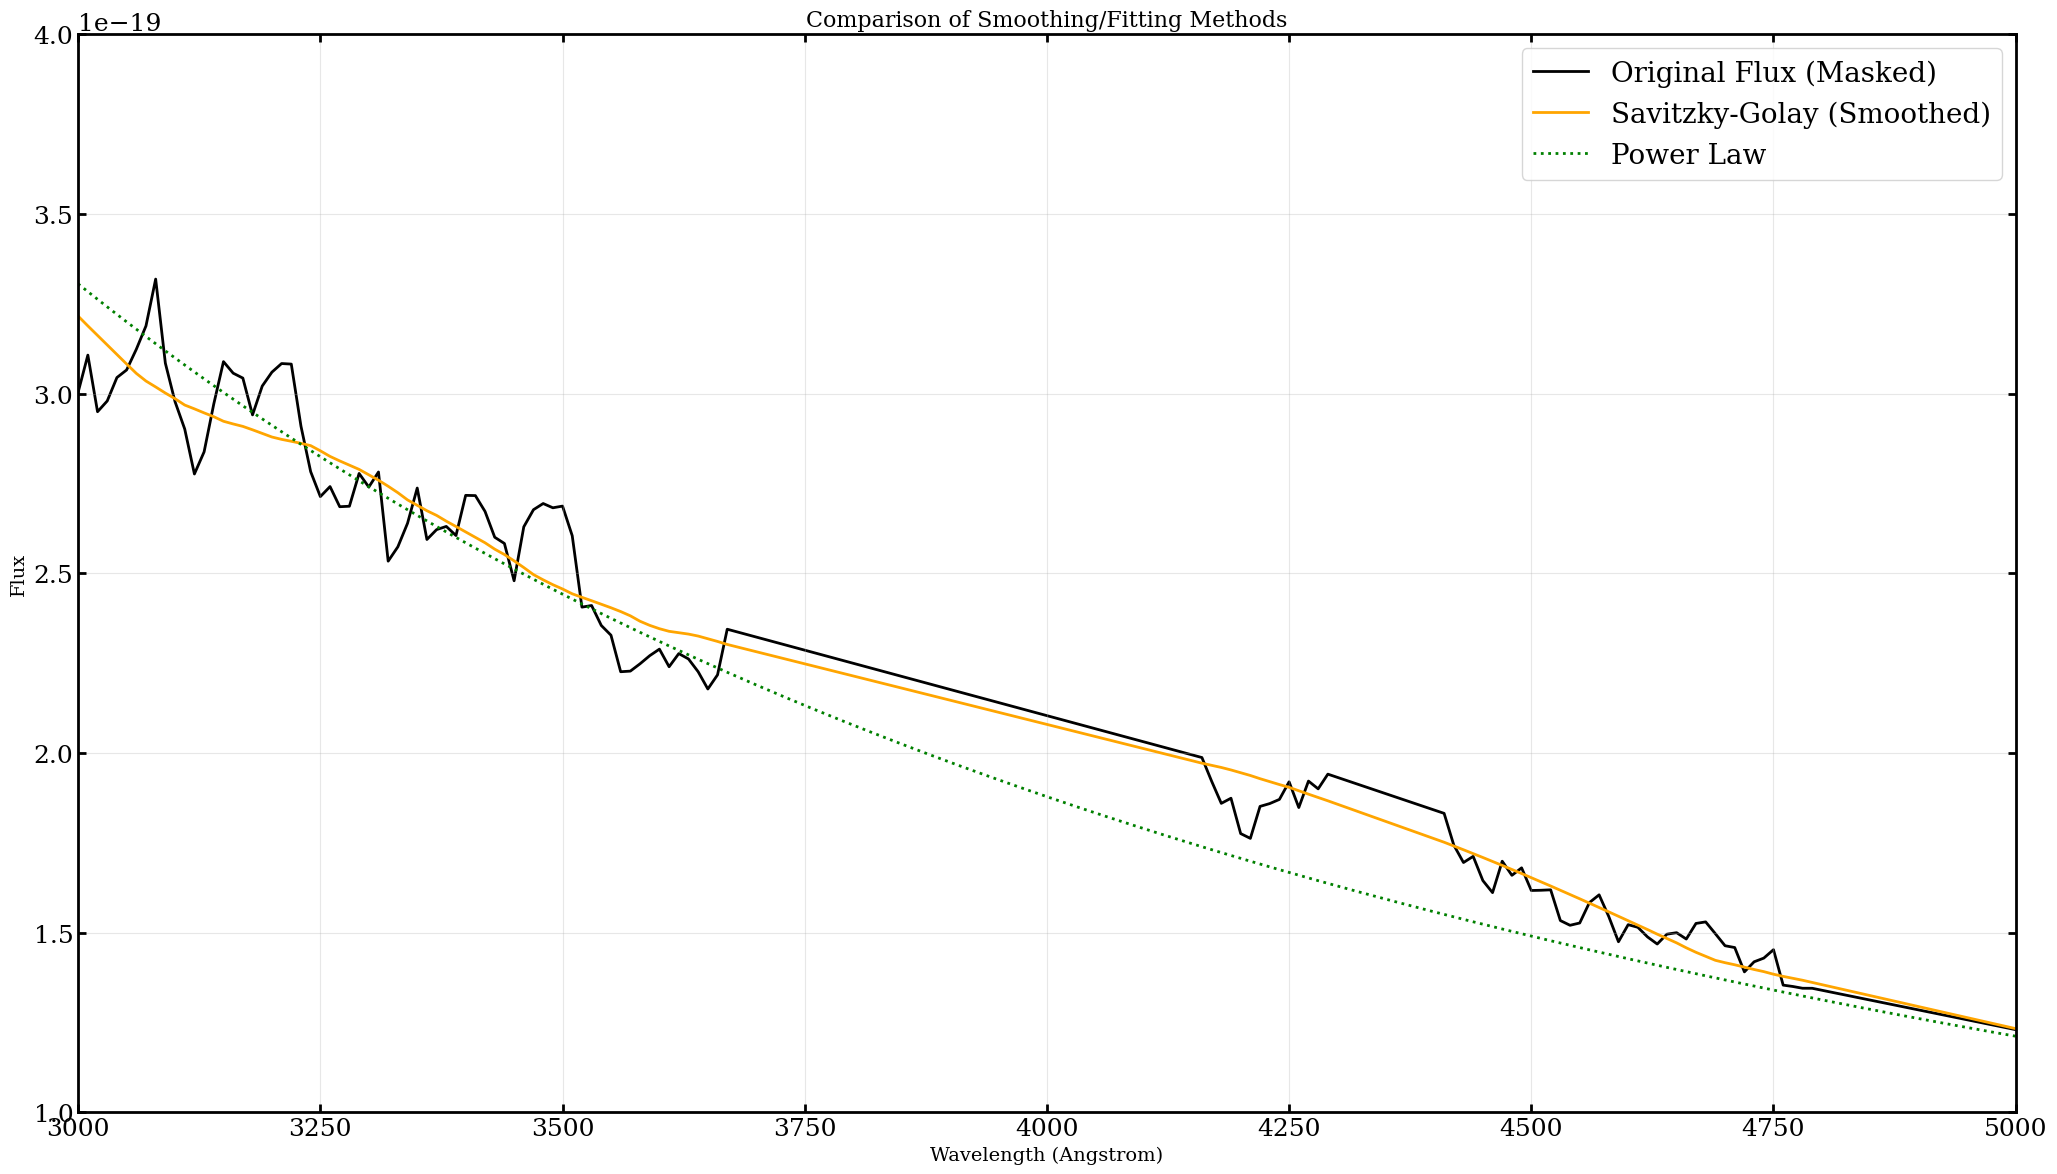

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
# 假设已经有了 wavelengths, averaged_flux, mask, valid_data, curve_clean
# 注意：为了演示，我使用 valid_data 来拟合 Poly 和 Powerlaw，但对 SG 使用全数据

x_data = wavelengths * 10000  # 转换为 Angstrom
y_data = curve_clean          # 使用插值后的数据

# --- Method 1: Savitzky-Golay (Corrected) ---
# 修正：先对整个插值后的数组做 filter，避免拼接处的伪影
sg_smooth = savgol_filter(y_data, window_length=window_len, polyorder=poly_order)

# --- Method 2: Polynomial (Global) ---
# 仅使用 valid_data 进行拟合，避免 mask 区域干扰
p_coeff = np.polyfit(x_data[valid_data], y_data[valid_data], deg=5) # 5阶多项式
poly_fit = np.polyval(p_coeff, x_data)

# --- Method 3: Power Law ---
def power_law(x, a, k):
    return a * (x**k)

try:
    # 初始猜测很重要，否则可能拟合失败
    popt, pcov = curve_fit(power_law, x_data[valid_data], y_data[valid_data], p0=[1e-16, -2])
    power_fit = power_law(x_data, *popt)
except:
    power_fit = np.zeros_like(x_data) # 如果拟合失败

# --- Method 4: Spline (推荐用于 Continuum) ---
# s 是平滑因子，控制紧贴程度。s 越大越平滑，s=0 经过所有点
spline = UnivariateSpline(x_data[valid_data], y_data[valid_data], s=1e-36)
# 注意：s 的值取决于你的数据量级，Flux 是 1e-18 级别，s 需要非常小或者先 Normalize 数据
spline_fit = spline(x_data)


# --- Plotting ---

# 原始数据
plt.plot(x_data[valid_data], averagers[0].average_flux[valid_data],
         color='black', lw=2, label='Original Flux (Masked)', zorder=0)

# 1. SG Filter
plt.plot(x_data[valid_data], sg_smooth[valid_data],
         color='orange', lw=2, label='Savitzky-Golay (Smoothed)')

# 2. Polynomial
# plt.plot(x_data, poly_fit,
#          color='blue', linestyle='--', lw=2, label='Polynomial (deg=5)')

# 3. Power Law
plt.plot(x_data, power_fit,
         color='green', linestyle=':', lw=2, label='Power Law')

# # 4. Spline (可选)
# plt.plot(x_data, spline_fit, color='red', lw=1, label='Spline')

plt.xlabel('Wavelength (Angstrom)', fontsize=14)
plt.ylabel('Flux', fontsize=14)
plt.title('Comparison of Smoothing/Fitting Methods', fontsize=16)
# plt.ylim(0, 2e-18)
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.ylim(1e-19,4e-19)
plt.xlim(3000,5000)
plt.grid(True, alpha=0.3)
plt.show()

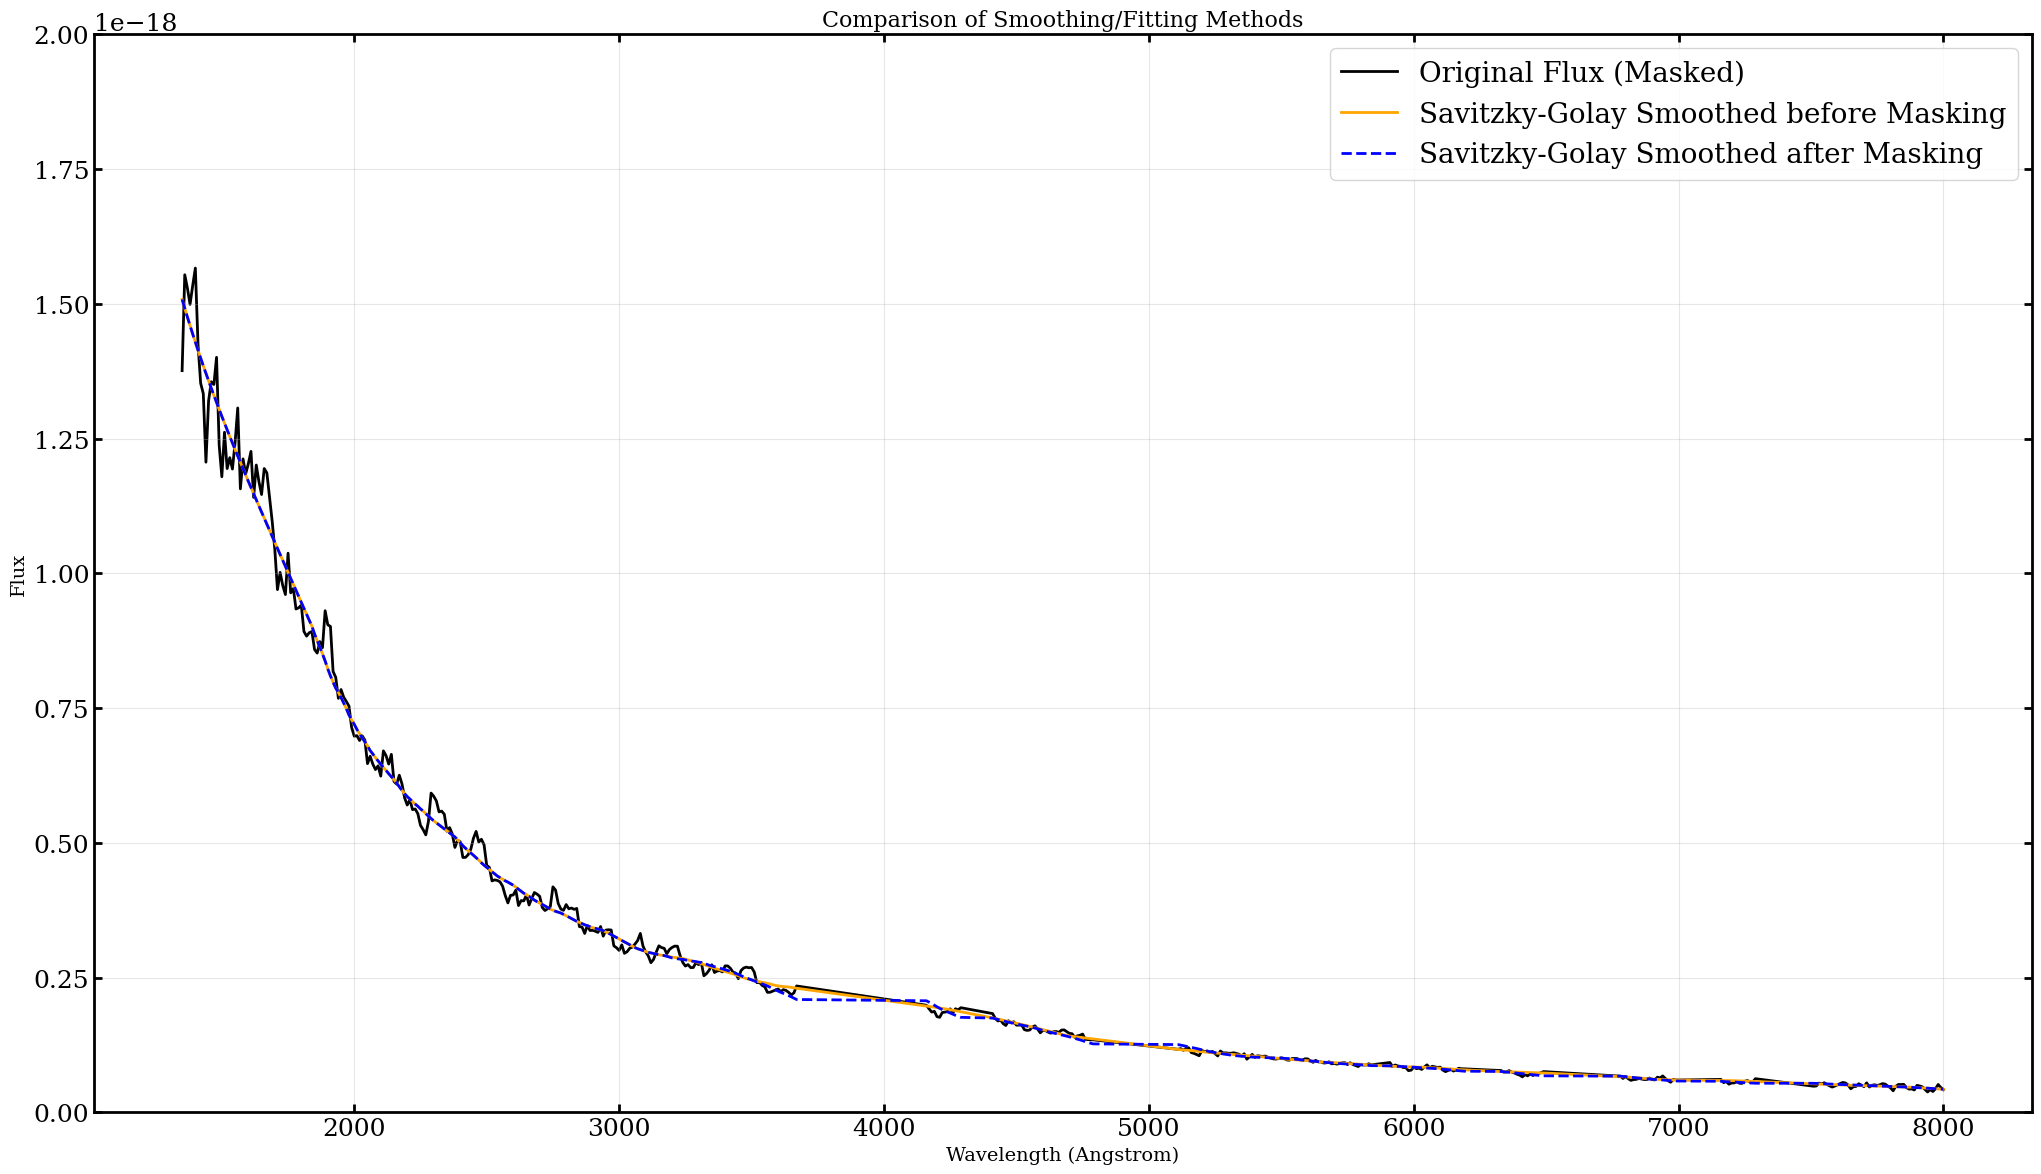

In [38]:
plt.plot(x_data[valid_data], averagers[0].average_flux[valid_data],
         color='black', lw=2, label='Original Flux (Masked)', zorder=0)

# 1. SG Filter
plt.plot(x_data[valid_data], sg_smooth[valid_data],
         color='orange', lw=2, label='Savitzky-Golay Smoothed before Masking')

# 2. Polynomial
plt.plot(x_data[valid_data], g0_smoothed_curve,
         color='blue', linestyle='--', lw=2, label='Savitzky-Golay Smoothed after Masking')

plt.xlabel('Wavelength (Angstrom)', fontsize=14)
plt.ylabel('Flux', fontsize=14)
plt.title('Comparison of Smoothing/Fitting Methods', fontsize=16)
plt.ylim(0, 2e-18)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()